<a href="https://colab.research.google.com/github/Niot-Espol/facetracker/blob/Naomi-facetracker/notebooks/PipelineBase_Naomi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Base del proyecto:
Este es un documento de partida para que puedan experimentar y entrenar su propios modelos, pueden generarse una copia y trabajar désde aquí, les recomiendo usar el material brindado más abajo, porfa una vez tengan su propio notebook guardenlo en sus propias ramas, De hecho GoogleColab les permite abrir el notebbok desde el github solo deben añadir el url o su usuario, siempre y cuando el repositorio sea público, lo cual si aplica para nuestro caso..

In [ ]:
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os


In [ ]:
# Descarga del dataset
print("Descargando el dataset desde Kaggle...")
ruta_base = kagglehub.dataset_download("mstjebashazida/affectnet")

# Kagglehub guarda los datos en una ruta local en caché.
# Buscamos la carpeta 'Train' dentro de esa ruta descargada:
ruta_train = os.path.join(ruta_base, 'archive (3)', 'Train')

# Nota: Si la carpeta 'archive (3)' no existe dentro del caché de kagglehub,
# la ruta directa suele ser simplemente: os.path.join(ruta_base, 'Train')





Descargando el dataset desde Kaggle...
Using Colab cache for faster access to the 'affectnet' dataset.


In [ ]:
#Carga de imagenes a tensorflow
print("\nCargando imágenes en el pipeline de TensorFlow...")

# Keras requiere un tamaño inicial fijo para crear los tensores
dataset_crudo = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    image_size=(256, 256),
    batch_size=32,
    label_mode='categorical'
)


Cargando imágenes en el pipeline de TensorFlow...
Found 16108 files belonging to 8 classes.


Clases detectadas: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Procesando y graficando 25 ejemplos...


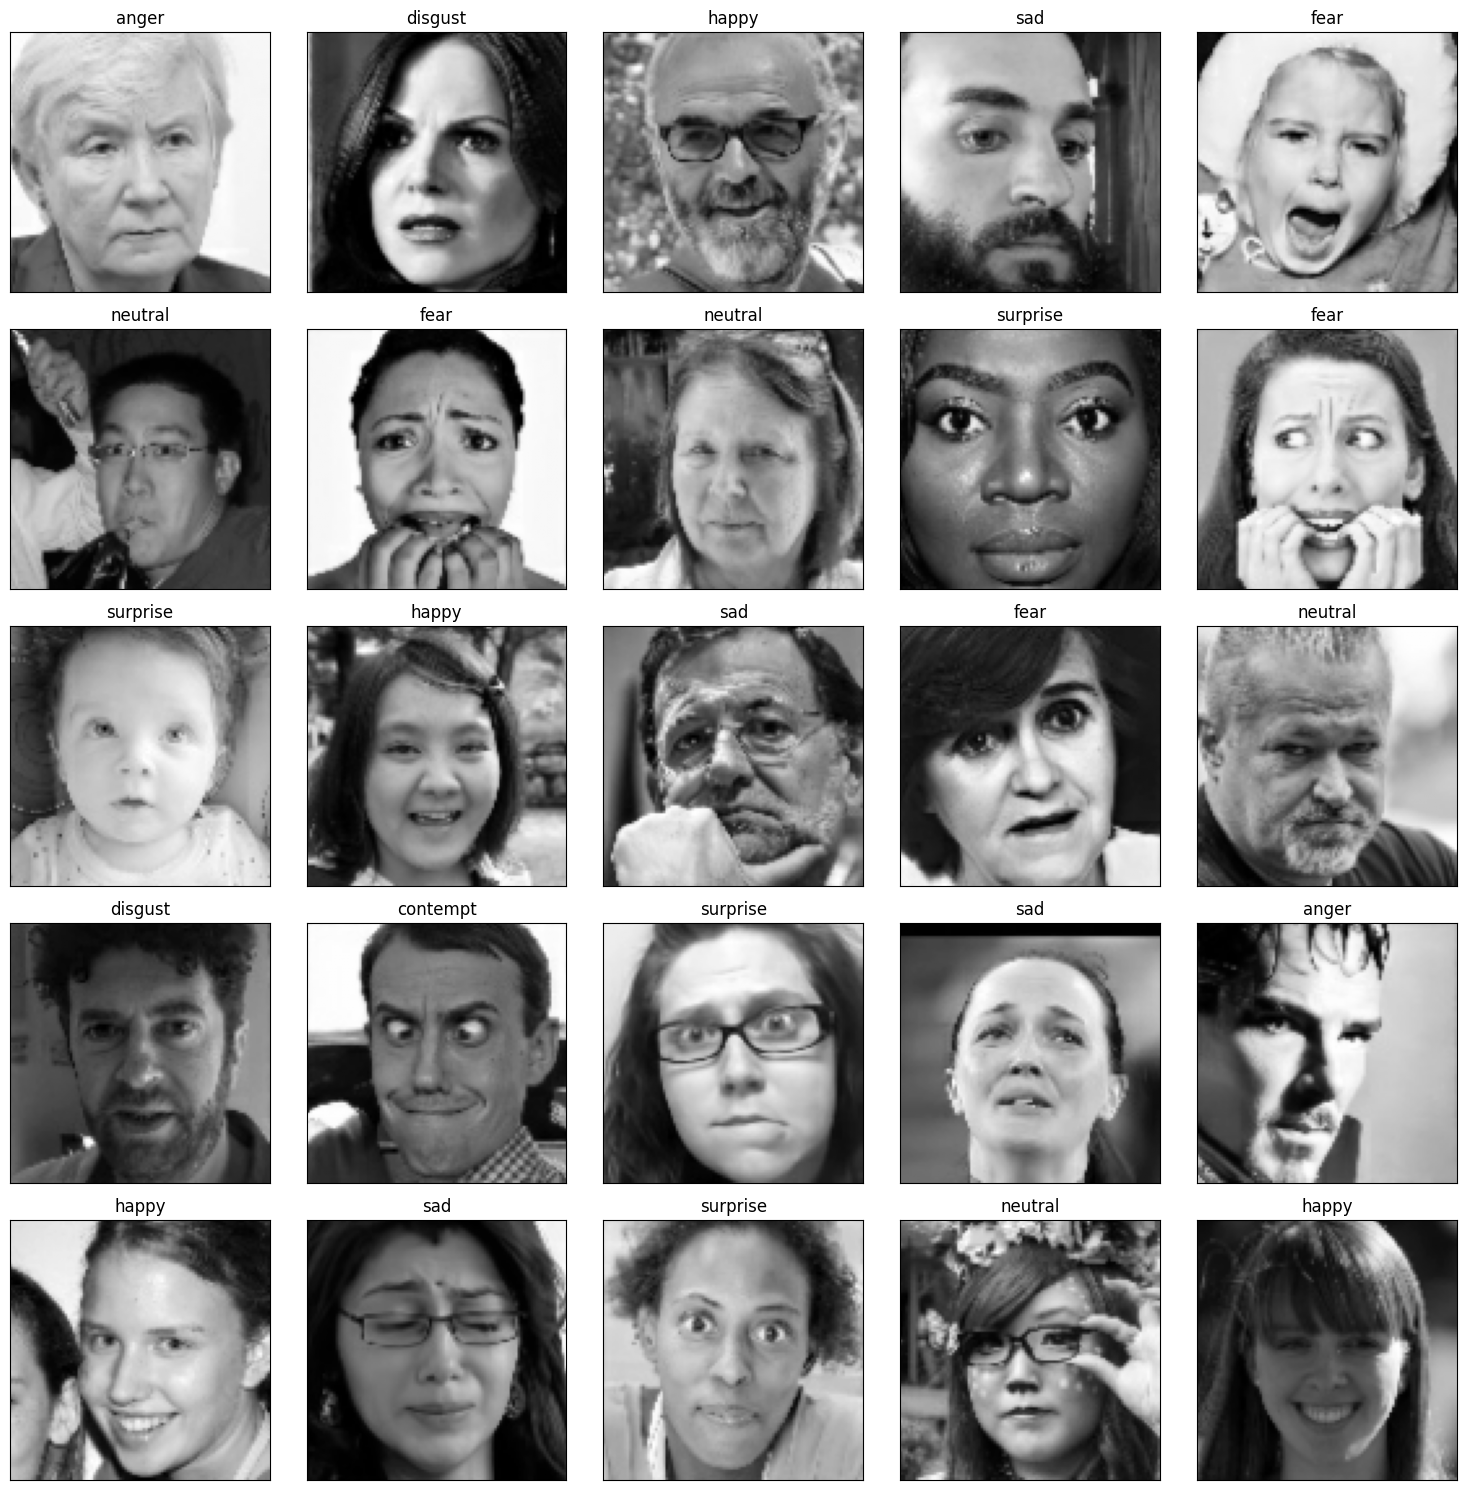

In [ ]:
# Inicializamos el diccionario
datos = {}

# .unbatch() rompe los bloques de 32 para que puedas iterar de 1 en 1
datos['train'] = dataset_crudo.unbatch()

# Extraemos los metadatos (los nombres de las emociones detectadas)
metadatos_clases = dataset_crudo.class_names
print("Clases detectadas:", metadatos_clases)

# Procesamiento de datos
print("\nProcesando y graficando 25 ejemplos...")

plt.figure(figsize=(15, 15))
TAMANO_IMG = 100 #este apartado lo pueden modificar a su gusto en caso de que quieran experimentar al respecto.

# Iteramos tomando exactamente 25 imágenes del pipeline
for i, (imagen, etiqueta) in enumerate(datos['train'].take(25)):

    # 1. Extraer el tensor y convertirlo a formato estándar de imagen (uint8)
    imagen_np = imagen.numpy().astype(np.uint8)

    # 2. Redimensionar a 100x100 usando OpenCV
    imagen_cv = cv2.resize(imagen_np, (TAMANO_IMG, TAMANO_IMG))

    # 3. Convertir de RGB a Escala de Grises
    imagen_cv = cv2.cvtColor(imagen_cv, cv2.COLOR_RGB2GRAY)

    # 4. Configurar la sub-gráfica en una cuadrícula de 5x5
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])

    # 5. Obtener la etiqueta (como usamos 'categorical', buscamos el índice del 1)
    indice_emocion = np.argmax(etiqueta.numpy())
    plt.title(metadatos_clases[indice_emocion])

    # 6. Mostrar la imagen en blanco y negro
    plt.imshow(imagen_cv, cmap='gray')

plt.tight_layout()
plt.show()

# Por hacer:


*   Tecnicas de aumento de datos (en el video se muestra una, si deciden usar otra con mejores resultados, adelante)
*   revisión de la información
*   hacer una primera prueba
*   Perfeccionar porterior a la prueba

Material de utilidad:
link: https://www.youtube.com/watch?v=DbwKbsCWPSg&t=239s

Este pipiline es el primer paso a dar para llevar a cabo el entrenamiento de su modelo, porfa espero que de cada uno puedo aplicar tecnicas distintas con el fin de obtener el mejor modelo posible, usen el video como ejemplo, si desean trabajar a color no hay problema, no se los daré resuelto porque no es el fin del proyecto, por ende aprendan a llevarlo a cabo ya que no es complejo.

Aquí adjunto la lista de reproducción completa de alguien que les sabrá dar las bases de manera precisa y como proceder, no teman por preguntar y avanzar con IA teman por que la IA haga todo, entiendan cada parte. EXITO CHICOS!

Una Vez cada uno tenga construido su modelo harémos pruebas en conjunto en busca de usar el que obtenga mejores resultados.

